# Breast Cancer Diagnosis: Building a Linear Classifier


**What this notebook covers:** We'll work with the Wisconsin Breast Cancer dataset (569 patient samples, 30 numeric features describing cell nuclei measurements) to predict whether a tumor is **Benign** or **Malignant**.

The goal is to get an overview of EDA, preprocessing and Evaluation Metrics

**The journey:**
| Step | What we do |
|---|---|
| **1. Data Analysis** | Explore the data: duplicates, missing values, class balance, distributions, outliers|
| **2. Preprocessing** | Split, impute, scale, and remove redundant features
| **3. Training & Evaluation** | Train a Linear Classifier and evaluate the predictions| Two different ways to solve the *same* linear classification problem |

Let's get started.

---


## Setup: Imports & Loading the Data

We start by silencing harmless warnings and importing the libraries we'll need throughout the notebook.

In [ ]:
import warnings

warnings.filterwarnings('ignore')

In [ ]:
import numpy as np
import pandas as pd # Import the pandas library for data manipulation and analysis
import matplotlib.pyplot as plt # Import the matplotlib.pyplot library for creating visualizations
from sklearn.model_selection import train_test_split # Import train_test_split function for splitting data
from sklearn.preprocessing import StandardScaler # Import StandardScaler for feature scaling
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, precision_score, recall_score, f1_score # Import ConfusionMatrixDisplay for visualization and confusion_matrix for calculation





In [ ]:
# The zeroth step is loading the data

df = pd.read_csv("/content/dataset.csv", index_col= 0) # Load the CSV file into a pandas DataFrame, using the first column as the index

## Step 1: Data Analysis

Before touching any model, we explore the dataset: its shape, what the columns mean, and whether anything looks off (duplicates, missing values, imbalance, weird distributions, outliers). This step builds the intuition we'll rely on later.

In [ ]:
print(df.shape)
 # Display the dimensions (number of rows and columns) of the DataFrame

(569, 32)


In [ ]:
# Lets explore the data
df.head(10) # Display the first 10 rows of the DataFrame to get a preview of the data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


The `id` column is just a row identifier with no predictive value, so we drop it before going further.

In [ ]:
df = df.drop('id', axis = 1)

In [ ]:
df.describe() # Generate descriptive statistics of the DataFrame's numerical columns

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
df.info() # Print a concise summary of the DataFrame, including data types and non-null values

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 no

### 1.1 Look for Duplicate Rows

Duplicate rows can silently bias a model by over- weighting certain samples, so we check for them first.

In [ ]:
duplicate_count = df.duplicated().sum() # Count the total number of duplicate rows in the DataFrame

print(f'The total numbers of duplicate rows found: {duplicate_count}') # Print the count of duplicate rows

The total numbers of duplicate rows found: 0


### 1.2 Look for Missing Values

Missing values need to be handled (dropped or imputed) before a model can use the data — here we just check how widespread the problem is.

In [ ]:
missing_values = df.isna().sum()

if missing_values.sum() == 0:
    print("There are no missing values.")
else:
    for col, count in missing_values.items():
        if count > 0:
            percentage_missing = (count / len(df)) * 100
            print(f'{col}: {percentage_missing:.1f}%')

There are no missing values.


### 1.3 Check for Class Imbalance

Our target is `diagnosis`: **B**enign or **M**alignant. If one class dominates, accuracy alone becomes a misleading metric, so it's worth knowing the split upfront.

In [ ]:
class_count = df['diagnosis'].value_counts()
print(class_count)
# Count the occurrences of each class in the 'diagnosis' column
percentage = df['diagnosis'].value_counts(normalize=True)*100 # Calculate the percentage of each class in the 'diagnosis' column

print(f'Count, Percentage of patients with Benign Tumors: {class_count[0]}, {percentage[0]:.1f}%') # Print the count and percentage for benign tumors
print(f'Count, Percentage of patients with Malignant Tumors: {class_count[1]}, {percentage[1]:.1f}%') # Print the count and percentage for malignant tumors

diagnosis
B    357
M    212
Name: count, dtype: int64
Count, Percentage of patients with Benign Tumors: 357, 62.7%
Count, Percentage of patients with Malignant Tumors: 212, 37.3%


### 1.4 Univariate Analysis

We look at numeric and categorical columns separately, then visualize the distribution of every numeric feature with histograms.

In [ ]:
numeric_cols = df.select_dtypes(include = 'number').columns # Select columns with numeric data types
print(f'Total number of numerical columns present : {len(numeric_cols)}') # Print the count of numeric columns

Total number of numerical columns present : 30


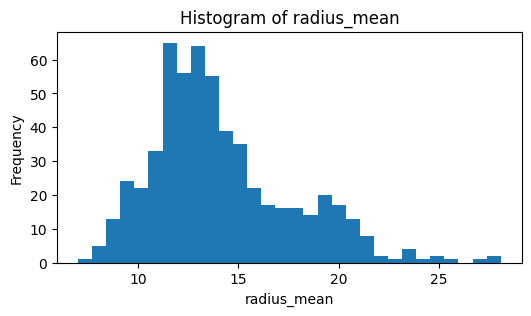

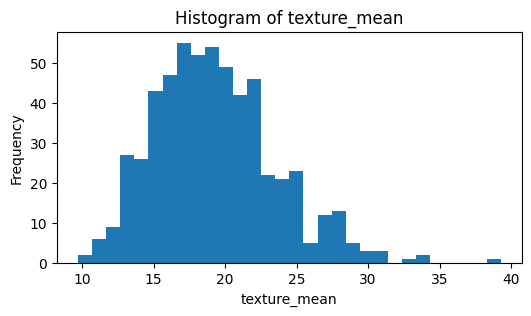

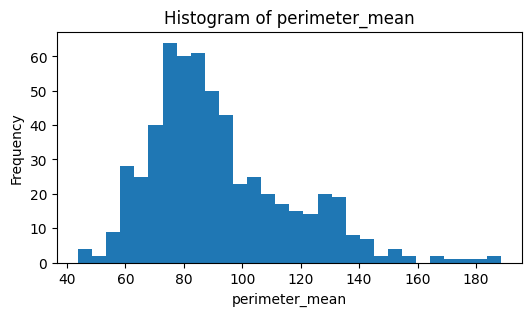

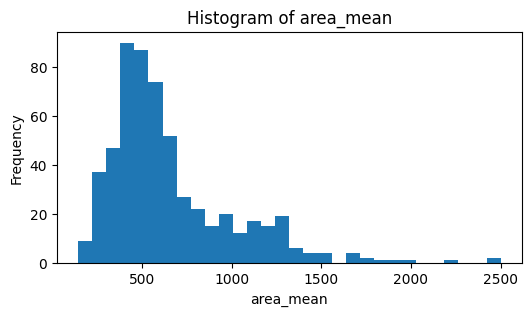

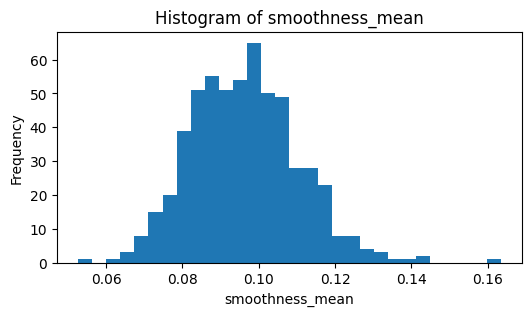

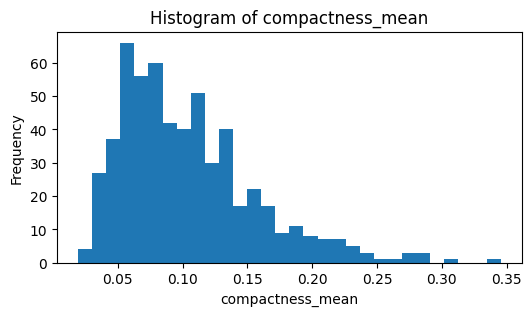

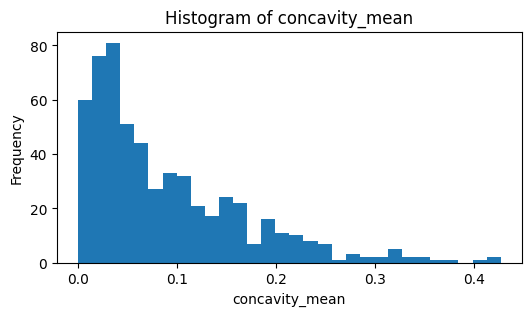

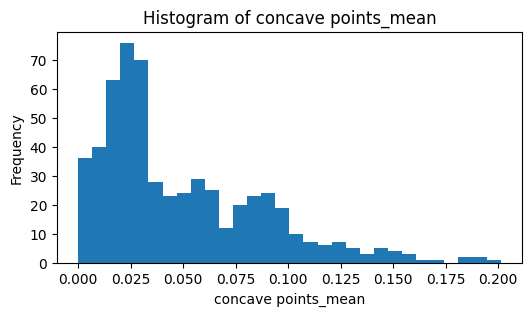

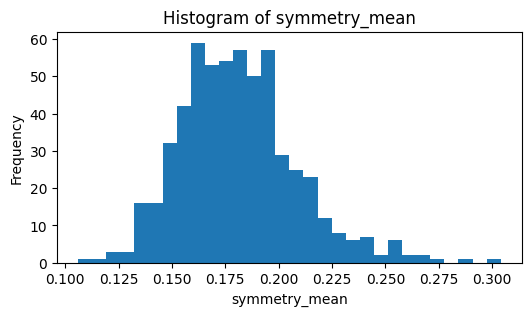

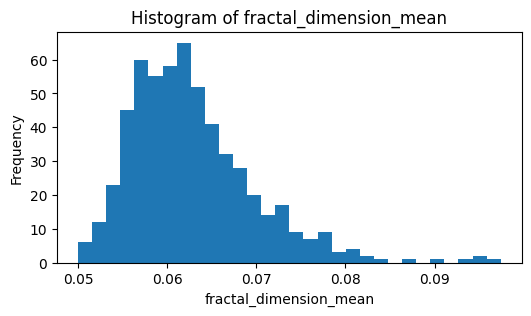

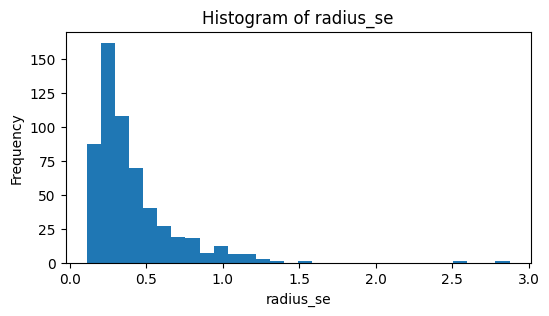

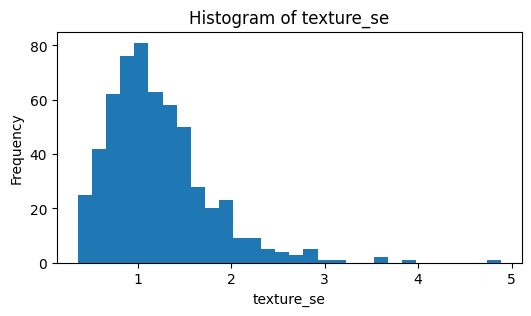

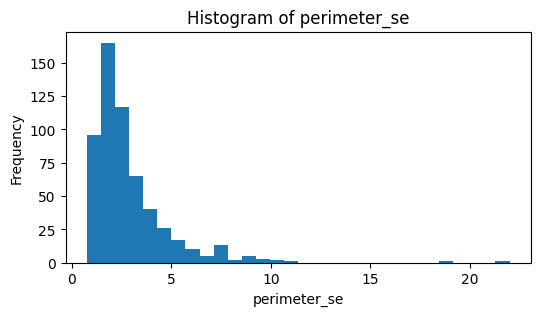

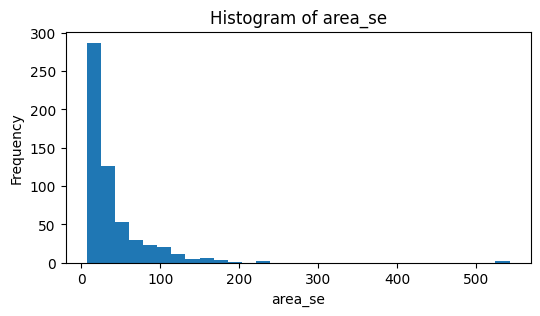

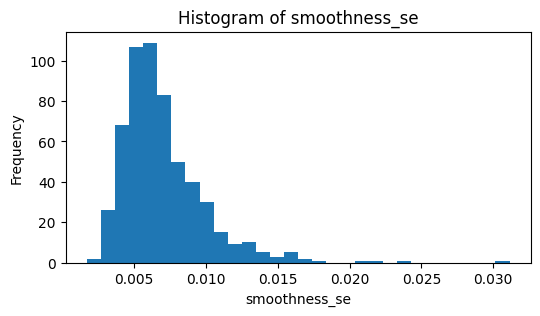

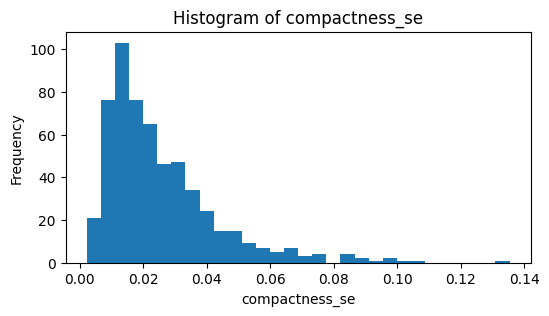

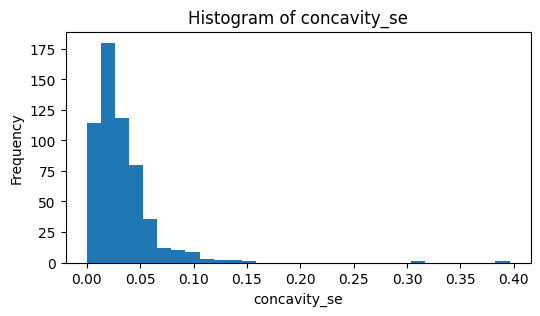

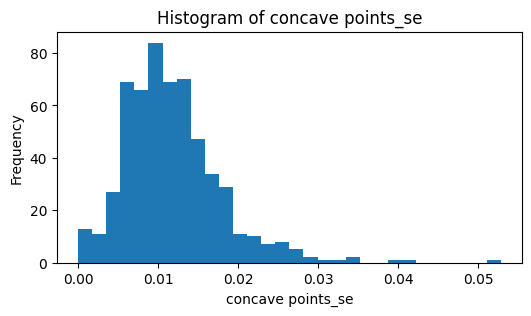

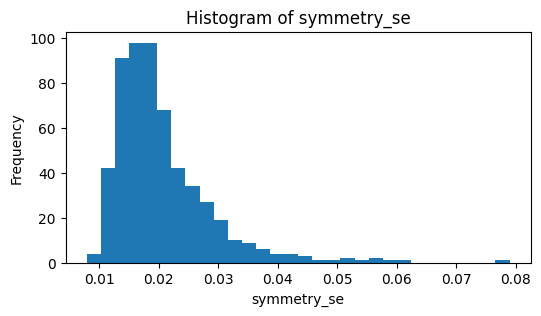

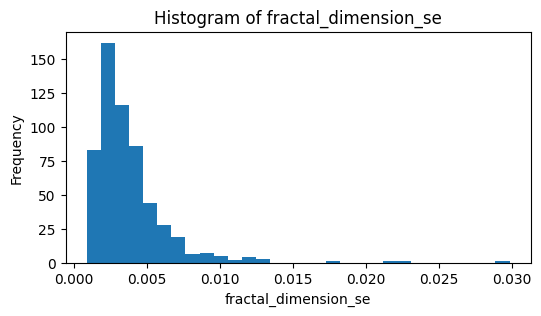

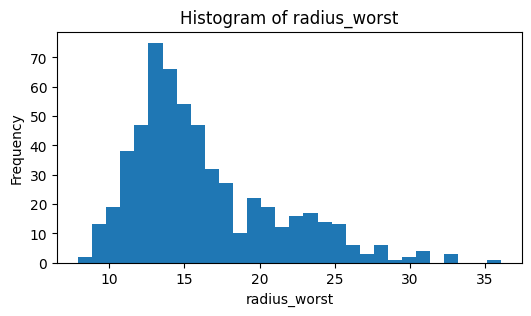

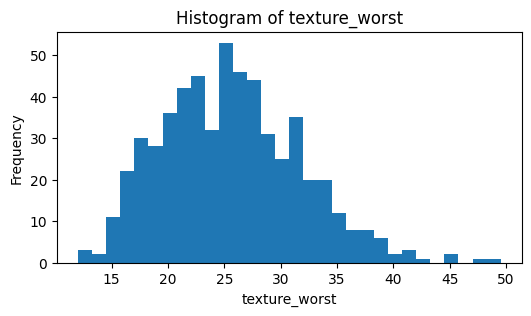

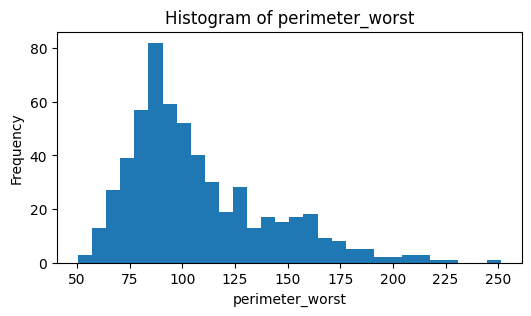

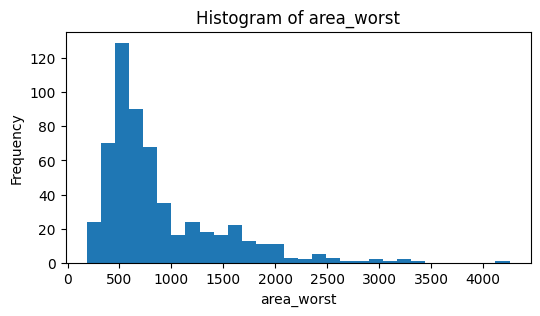

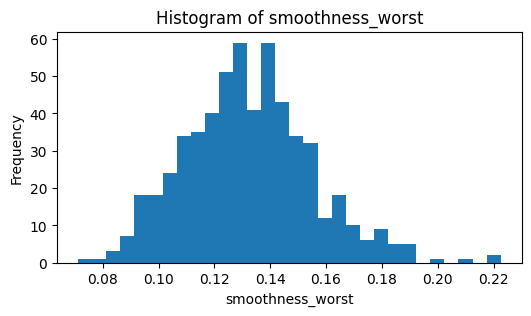

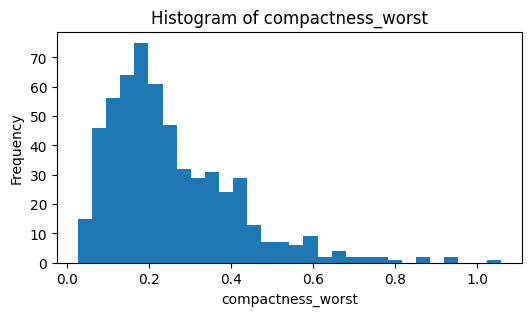

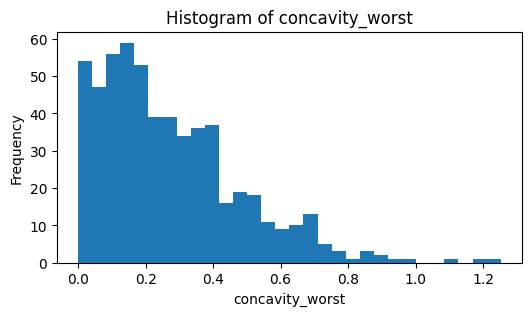

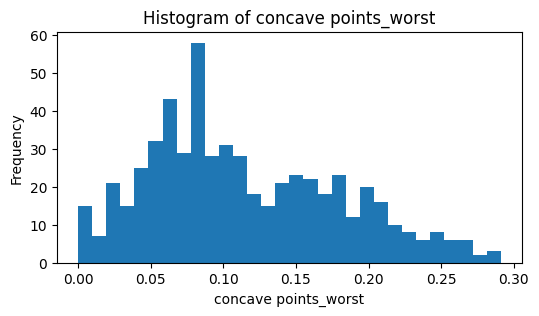

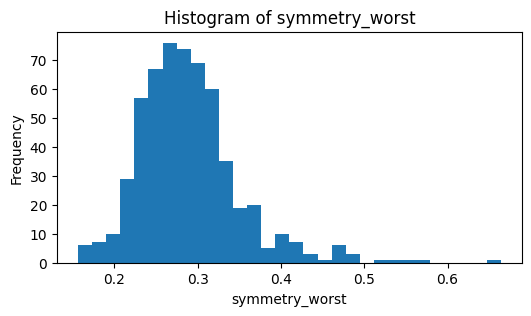

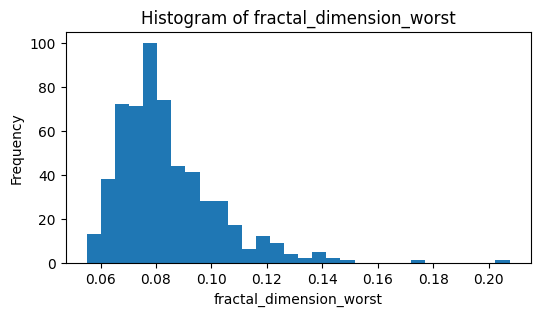

In [ ]:
for col in numeric_cols: # Iterate through each numeric column

    plt.figure(figsize=(6, 3)) # Create a new figure for each histogram with a specified size

    plt.hist( # Generate a histogram
        df[col].dropna(), # Use data from the current column, dropping any missing values
        bins=30 # Set the number of bins for the histogram
    )

    plt.title(f"Histogram of {col}") # Set the title of the histogram
    plt.xlabel(col) # Set the x-axis label
    plt.ylabel("Frequency") # Set the y-axis label

    plt.show() # Display the histogram

In [ ]:
categorical_cols = df.select_dtypes(include = 'object').columns # Select columns with categorical data types
print(f'Categorical Columns : {list(categorical_cols)}') # Print the list of categorical column names

Categorical Columns : ['diagnosis']


### 1.5 Check for Outliers

Using the IQR (Interquartile Range) method, we flag values that fall far outside the typical range for each feature.


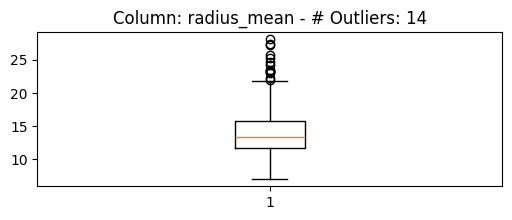

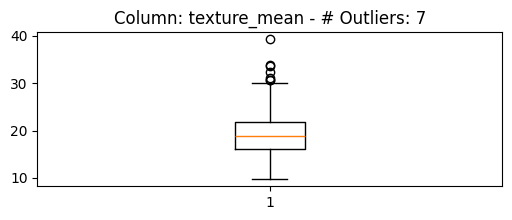

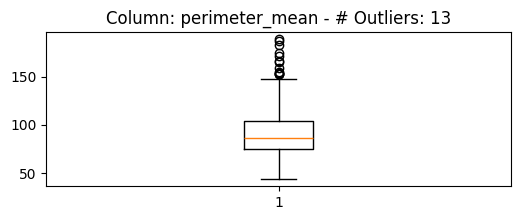

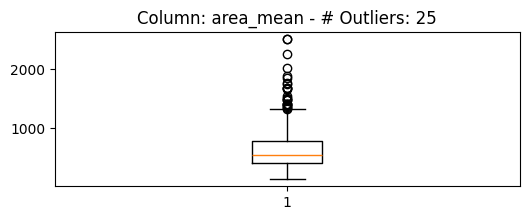

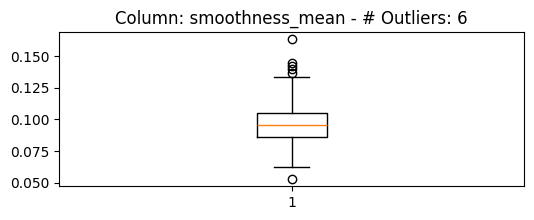

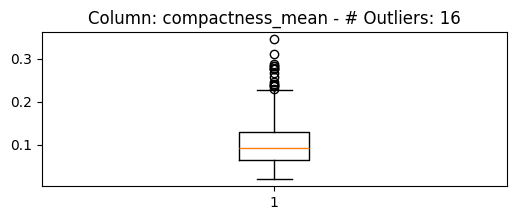

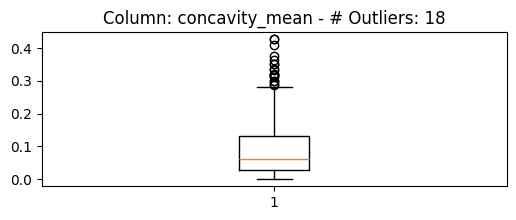

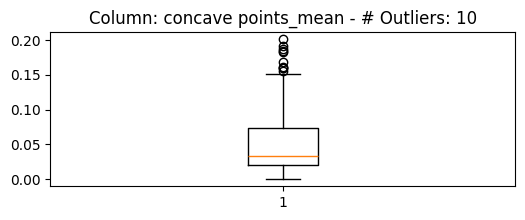

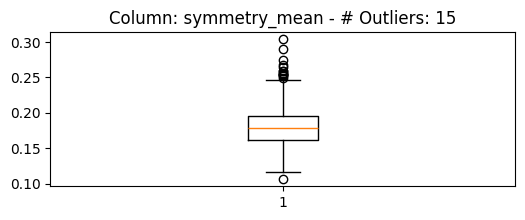

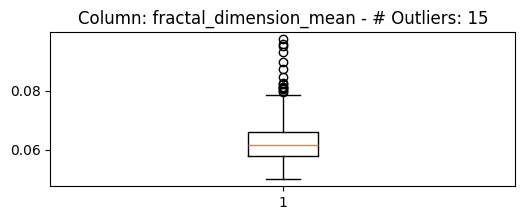

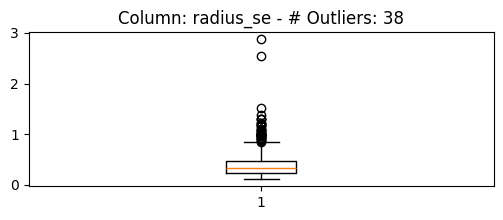

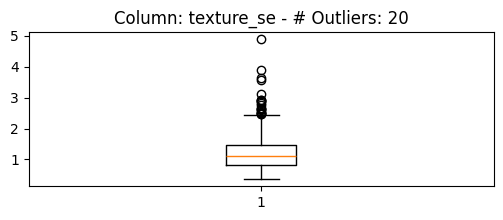

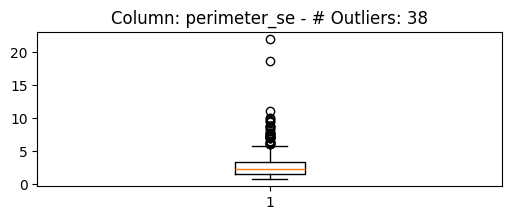

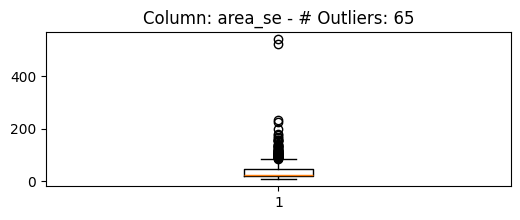

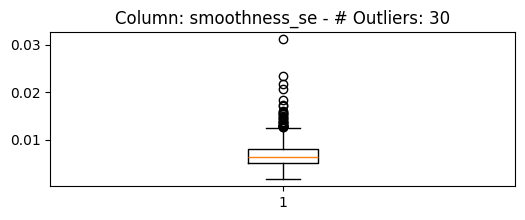

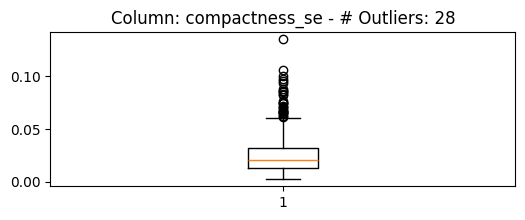

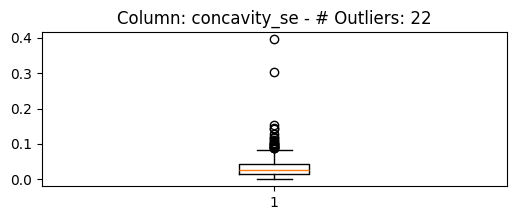

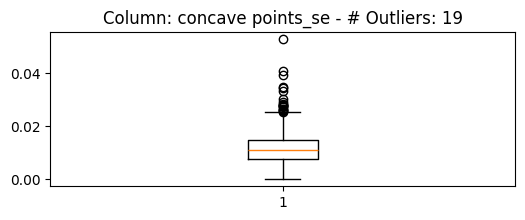

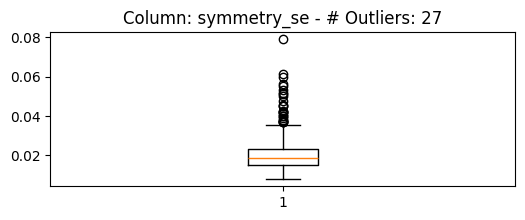

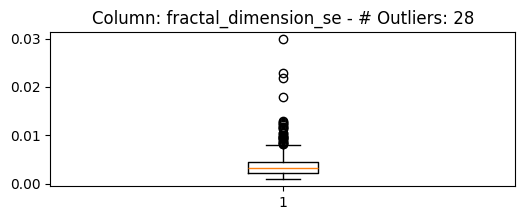

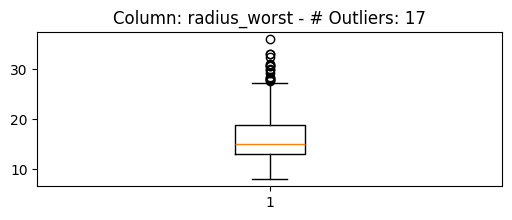

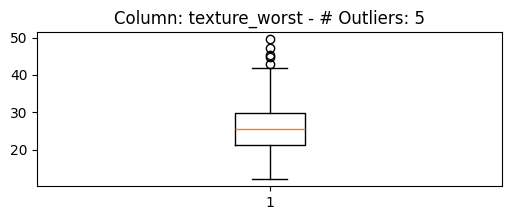

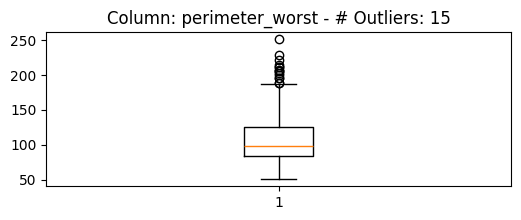

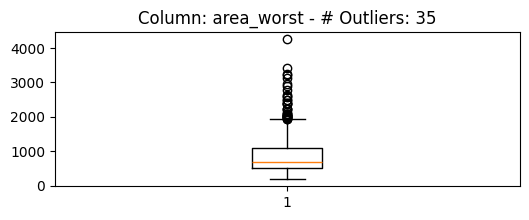

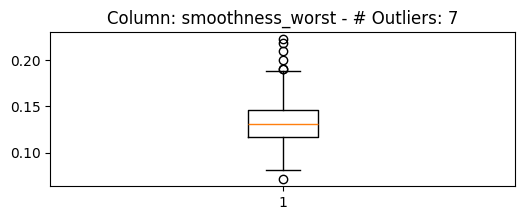

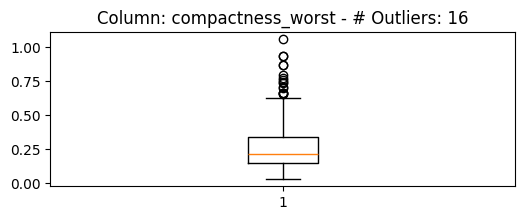

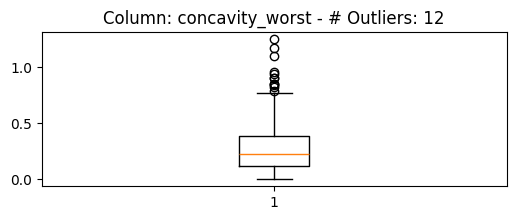

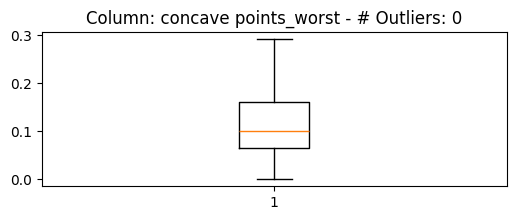

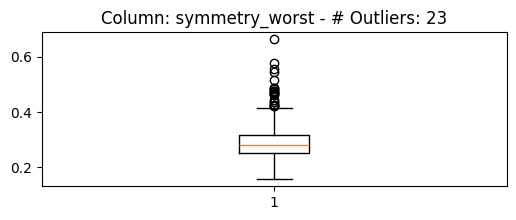

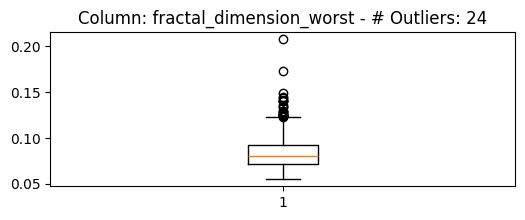

In [ ]:
for col in numeric_cols: # Iterate through each numeric column

  Q1 = df[col].quantile(0.25) # Calculate the first quartile (25th percentile)
  Q3 = df[col].quantile(0.75) # Calculate the third quartile (75th percentile)
  IQR = Q3 - Q1 # Calculate the Interquartile Range (IQR)

  lower = Q1 - 1.5*IQR # Calculate the lower bound for outlier detection
  upper = Q3 + 1.5*IQR # Calculate the upper bound for outlier detection

  outlier_mask = (df[col] < lower) | (df[col] > upper) # Boolean mask: True where the value is an outlier
  num_outliers = outlier_mask.sum() # Count the number of outliers based on IQR

  plt.figure(figsize = (6,2)) # Create a new figure for each box plot
  plt.boxplot(df[col].dropna()) # Generate a box plot for the current column, dropping missing values

  plt.title(f'Column: {col} - # Outliers: {num_outliers}') # Set the title of the box plot including the outlier count (this is the count found BEFORE imputation)

  plt.show() # Display the box plot





## Step 2: Preprocessing

Now we prepare the data for modeling. This means splitting it into train/test sets, filling any missing values, scaling features so they're on comparable ranges, and removing redundant (highly correlated) features.

### 2.1 Split Data into Train and Test Sets

We hold out 20% of the data as a test set that the model never sees during training. `stratify=y` ensures both sets keep the same Benign/Malignant ratio as the full dataset.

In [ ]:
X = df.drop('diagnosis', axis = 1) # Create feature matrix X by dropping the 'diagnosis' column
y = np.where(df['diagnosis'] == 'M', 1, -1) # Create target vector y: 1 for Malignant, -1 for Benign


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y) # Split data into training and test sets (80% train, 20% test)
# 'random_state' ensures reproducibility, 'stratify=y' maintains the same proportion of target classes in both splits

In [ ]:
print(f"Total patients: {len(df)}") # Print the total number of patients in the original dataset
print(f"Training set size: {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)") # Print the size and percentage of the training set
print(f"Test set size: {len(X_test)} ({len(X_test)/len(df)*100:.0f}%)") # Print the size and percentage of the test set

print(
f"  Class split in training: " # Print header for class distribution in training set
    f"{(y_train==-1).sum()/len(X_train):.1%} Benign, "
    f"{(y_train==1).sum()/len(X_train):.1%} Malignent"
)

print(
    f"  Class split in test:     " # Print header for class distribution in test set
    f"{(y_test==-1).sum()/len(X_test):.1%} Benign, "
    f"{(y_test==1).sum()/len(X_test):.1%} Malignant"
)

print("\nstratify=y ensures both splits have the same % of Benign vs Malignant cases") # Explain the purpose of stratify=y

Total patients: 569
Training set size: 455 (80%)
Test set size: 114 (20%)
  Class split in training: 62.6% Benign, 37.4% Malignent
  Class split in test:     63.2% Benign, 36.8% Malignant

stratify=y ensures both splits have the same % of Benign vs Malignant cases


### 2.2 Imputing Outliers

In [ ]:
impute_outliers_Flag = True  # Set to True to impute outliers with the column median, False to just visualize/count them as before

for col in numeric_cols: # Iterate through each numeric column

  Q1 = X_train[col].quantile(0.25) # Calculate the first quartile (25th percentile)
  Q3 = X_train[col].quantile(0.75) # Calculate the third quartile (75th percentile)
  IQR = Q3 - Q1 # Calculate the Interquartile Range (IQR)

  lower = Q1 - 1.5*IQR # Calculate the lower bound for outlier detection
  upper = Q3 + 1.5*IQR # Calculate the upper bound for outlier detection

  outlier_mask = (X_train[col] < lower) | (X_train[col] > upper) # Boolean mask: True where the value is an outlier
  num_outliers = outlier_mask.sum() # Count the number of outliers based on IQR




  if impute_outliers_Flag and num_outliers > 0:
    median_val = X_train.loc[~outlier_mask, col].median() # Median computed from non-outlier values only, so the outliers themselves don't skew the value used to replace them
    X_train.loc[outlier_mask, col] = median_val # Replace each outlier with that column's median

    # apply the SAME train-fit bounds and value to test no new stats from X_test
    test_outlier_mask = (X_test[col] < lower) | (X_test[col] > upper)
    X_test.loc[test_outlier_mask, col] = median_val


### 2.3 Scaling

Our features are measured on very different scales (e.g. `area_mean` is in the hundreds, `smoothness_mean` is near 0.1). `StandardScaler` rescales each feature to have mean 0 and standard deviation 1, which matters a lot for linear models. Note: the scaler is **fit only on training data**, then applied to the test set, this avoids leaking test set information.

In [ ]:
scaler = StandardScaler() # Initialize StandardScaler

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols]) # Fit the scaler on training numeric columns and transform them

In [ ]:
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols]) # Transform the test set's numeric columns using the scaler fitted on the training data

### 2.4 Visualizing Correlation

With 30 features, some are likely measuring very similar things (e.g. `radius_mean` and `perimeter_mean`). A correlation heatmap helps us spot these relationships visually before we decide what to do about them.

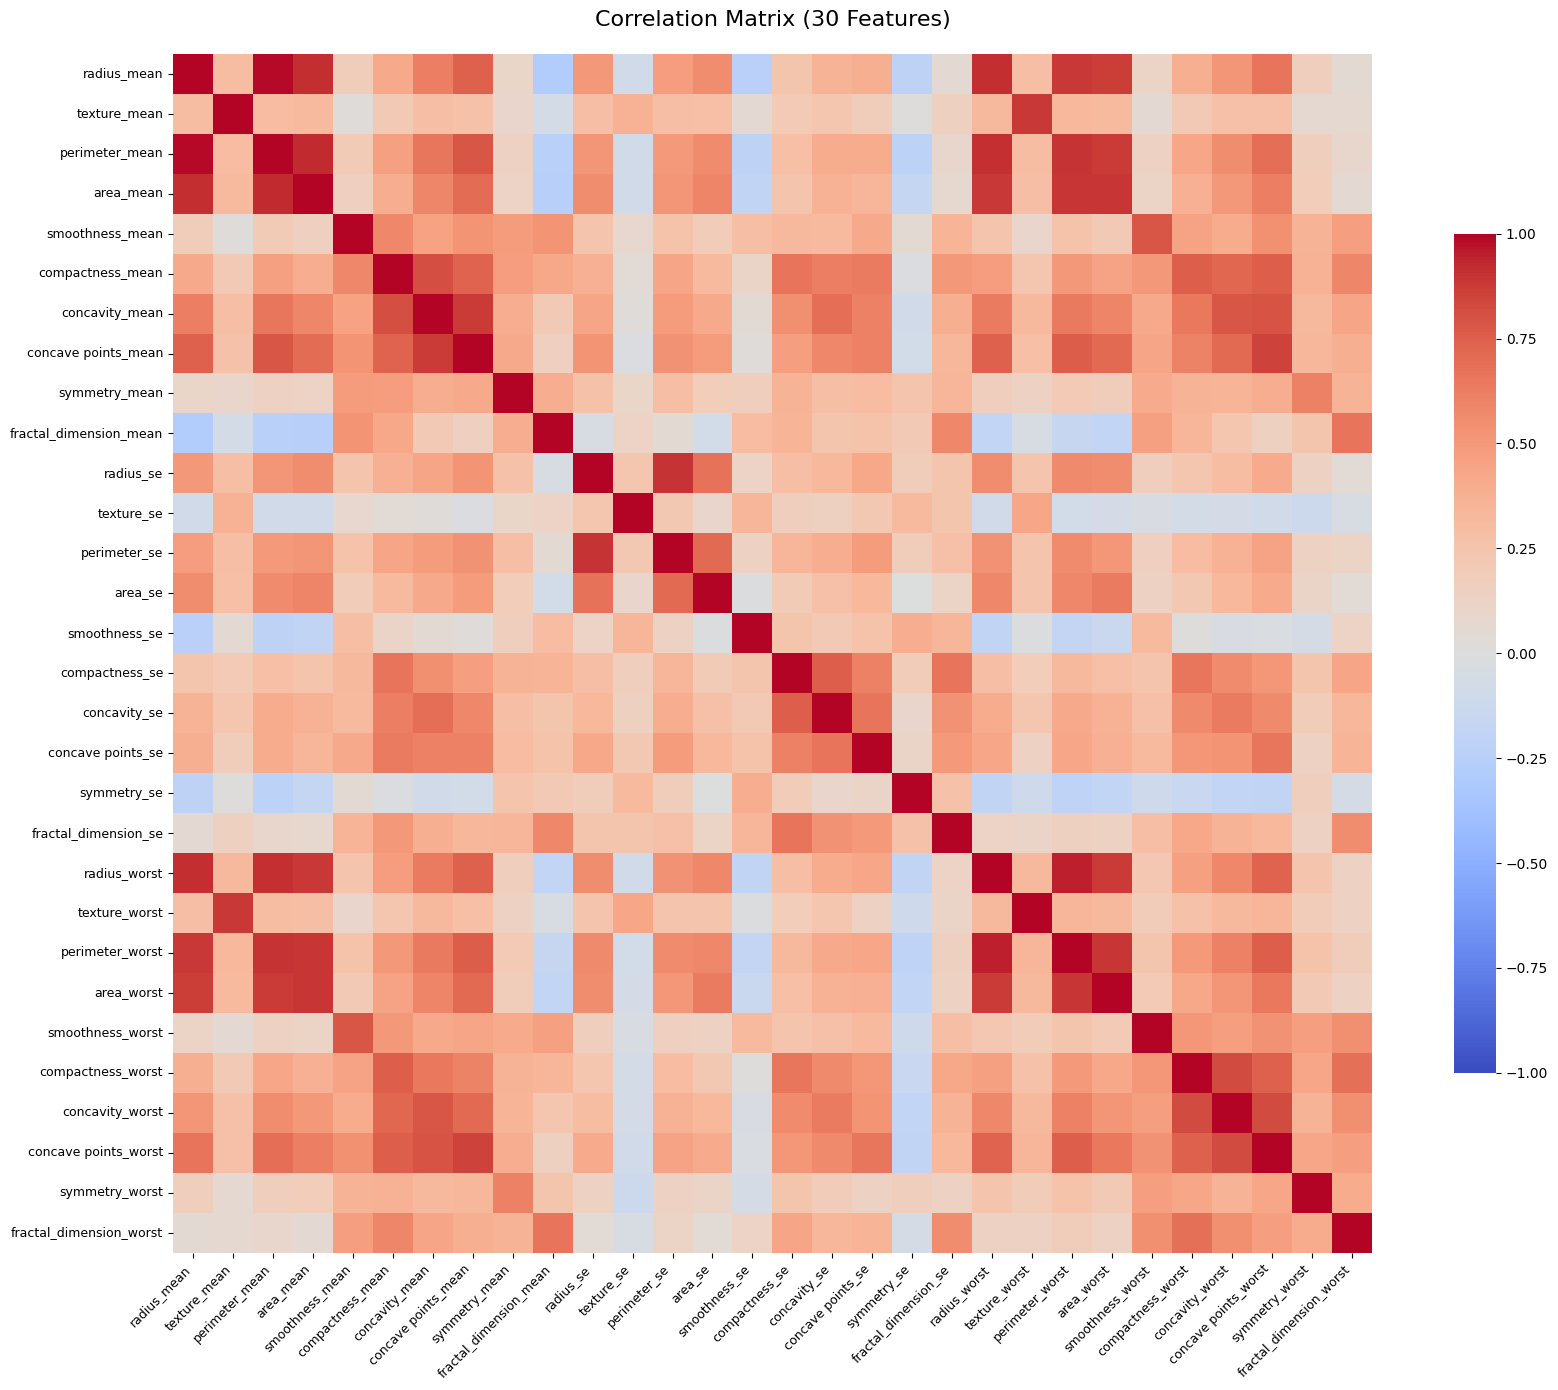

In [ ]:
corr_matrix = X_train.corr()
plt.figure(figsize=(18, 14))


sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"shrink": 0.7}
)

plt.xticks(fontsize=9, rotation=45, ha='right')
plt.yticks(fontsize=9, rotation=0)

plt.title('Correlation Matrix (30 Features)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

### 2.5 Removing Highly Correlated Features

Highly correlated (redundant) features can make linear models less stable. Here we drop one feature from any pair with a correlation above 0.9, cutting our feature count.

In [ ]:
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

corr_threshold = 0.9

to_drop = [
    col for col in upper.columns
    if any(upper[col] > corr_threshold)
]

X_train_reduced = X_train.drop(columns=to_drop)
X_test_reduced = X_test.drop(columns=to_drop)

print(f"Original features: {X_train.shape[1]}")
print(f"Remaining features: {X_train_reduced.shape[1]}")

X_train = X_train_reduced
X_test = X_test_reduced

Original features: 30
Remaining features: 25


## Step 3: Training and Evaluation

With clean, scaled, de-correlated features ready, we now build a linear classifier.

### 3.1 Linear Classifier

This classifier solves for weights `w`. We fit it on the training data and generate predictions on the held-out test set.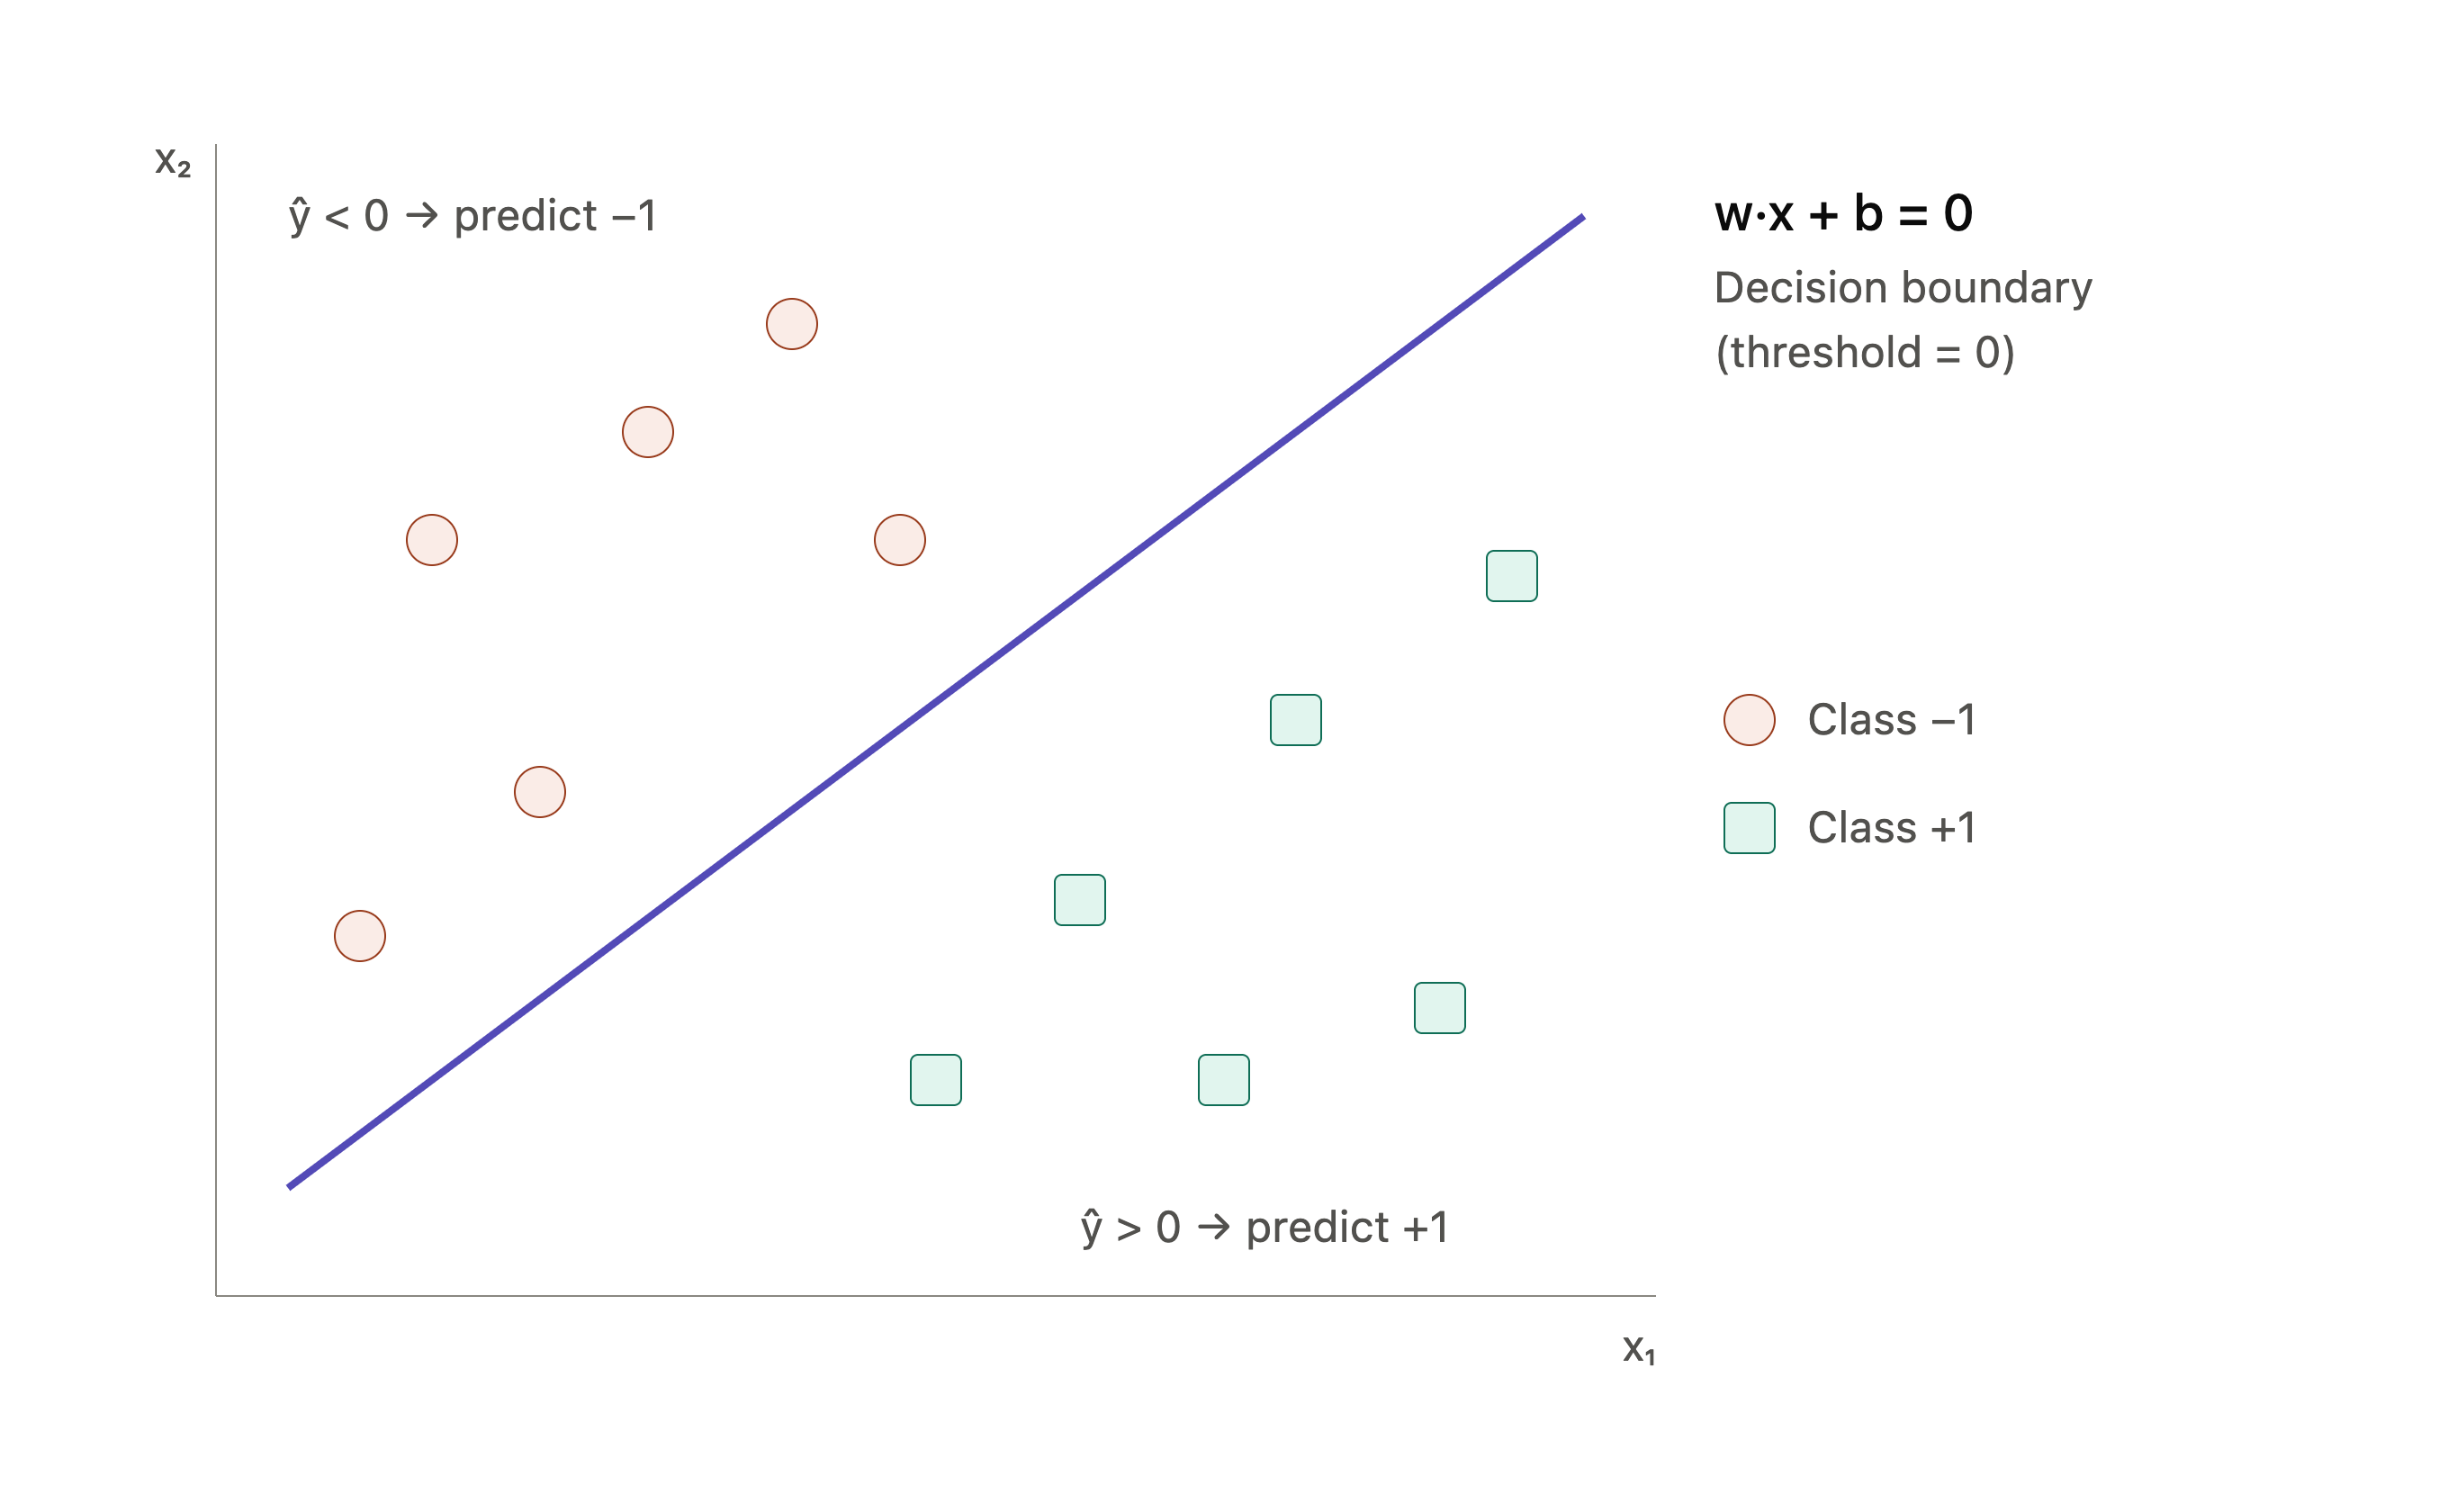

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred[:10])

[-0.93776179  1.50591109 -0.5485295   0.06313395 -0.51187422 -0.19279379
  0.40246844 -0.88284103 -0.92386062 -0.71767381]


In [ ]:
threshold = 0 # why did we keep the threshold as 0?

y_pred = np.where(y_pred > threshold, 1, -1)

**Results**

Accuracy : 98.2%
Precision: 1.000
Recall   : 0.952
F1 Score   : 0.976


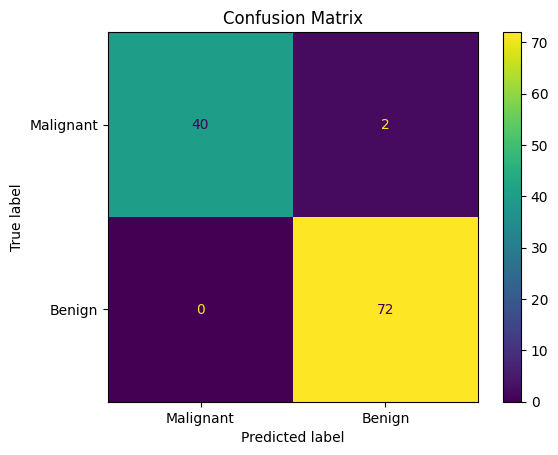

In [ ]:
accuracy = np.mean(y_pred == y_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy : {accuracy*100:.1f}%')
print(f'Precision: {precision:.3f}')
print(f'Recall   : {recall:.3f}')
print(f'F1 Score   : {f1:.3f}')

cm = confusion_matrix(y_test, y_pred, labels = [1, -1]) # Calculate the confusion matrix
disp = ConfusionMatrixDisplay( # Initialize ConfusionMatrixDisplay with the calculated confusion matrix
    confusion_matrix=cm,
    display_labels = ['Malignant', 'Benign']
)

disp.plot() # Plot the confusion matrix

plt.title("Confusion Matrix") # Set the title of the plot
plt.show() # Display the plot

## Summary

We took the Wisconsin Breast Cancer dataset from a raw CSV to a working classifier:

1. **Data analysis**: 569 patients, 30 numeric features, no duplicates, no missing values. The classes are moderately imbalanced (62.7% Benign / 37.3% Malignant), so we report precision, recall and F1 alongside accuracy. Many features are right-skewed and have IQR outliers.
2. **Preprocessing**: we split first (stratified 80/20). Every statistic after that (outlier bounds, replacement medians, scaler mean/std, the correlation filter) is learnt from the **training set only** and applied unchanged to the test set.
3. **Model**: a linear regression fit on labels −1 / +1, turned into a classifier by predicting Malignant when the output is above 0.

| Impute Outliers | Features kept | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|
| False | 20 | 95.6% | 1.00 | 0.88 | 0.94 |
| True  | 25 | 98.2% | 1.00 | 0.95 | 0.98 |

**Takeaways**
- **Precision is 1.00 in both runs**: no benign patient was flagged as malignant. Every error is a **false negative**, a missed cancer, which is the costlier mistake in diagnosis. That makes **recall** the metric to watch here, not accuracy.
- **Outlier imputation improved recall on this split, but read the gain with care.** Imputing changed the feature correlations, so the 0.9 filter kept 25 features instead of 20. Two things changed at once.
- **Split before you fit anything.** Fitting the imputer, scaler or feature filter on the full data would leak test information into training.



---






## Take-Home Problem 1


Explain why do we impute outliers **after splitting** into train and test set, when we could have done that **before splitting**?

## Take-Home Problem 2
Which of the following datasets can be classified by a linear classifier and why?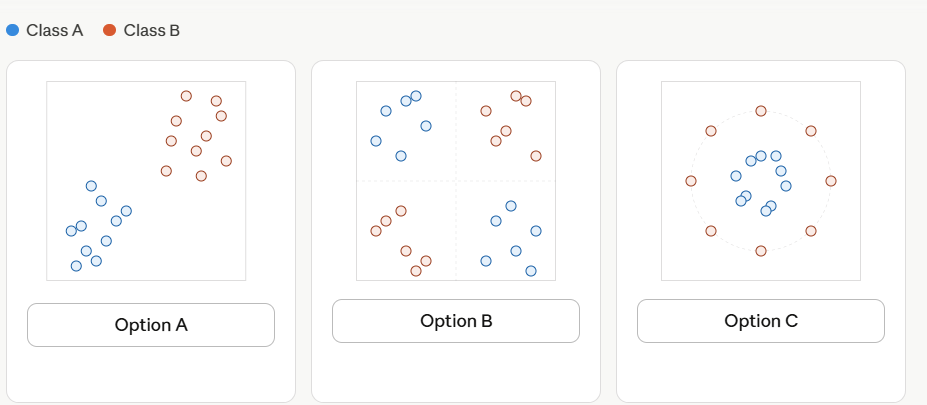


## Take-Home Problem 3


Suppose some numerical features in your dataset are highly skewed. How would you identify the **skewness**, and what techniques would you use to address it before training a machine learning model?

## Take-Home Problem 4

In Section 2.5, change the value of `corr_threshold` to 0.8, 0.7, 0.6, 0.5, 0.4 and plot the performance.
